# Unsupervised Learning: Clustering & Dimensionality Reduction
### A Practical Notebook for Students by Prof A. S. Olayinka

---

**Topics Covered:**
1. 📍 K-Means Clustering
2. 🌫️ Gaussian Mixture Models (GMM)
3. 📉 Principal Component Analysis (PCA)

Each section includes:
- ✅ A complete worked example with visualizations
- 🔨 A hands-on **To-Do** exercise for you to complete
- ❓ **Reflection Questions** to check your understanding

> **How to use this notebook:** Run each cell top to bottom. Read the explanations, study the code, then complete the To-Do tasks in the designated cells.

---

## ⚙️ Setup — Run This First!

In [1]:
# Install any missing packages
# !pip install scikit-learn matplotlib seaborn numpy pandas -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs, load_digits, make_moons
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings('ignore')

# Global plot style
plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor': '#F5F5F5',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 12
})
COLORS = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


---
# 📍 PART 1: K-Means Clustering

## What is K-Means?

K-Means partitions a dataset into **K clusters** by:
1. Randomly placing K **centroids** (the "darts" on the dartboard)
2. Assigning every data point to its **nearest centroid**
3. Moving each centroid to the **mean** of its assigned points
4. Repeating until nothing changes

```
Initialize centroids  →  Assign points  →  Update centroids  →  [Converged?]
        ↑                                                              |
        └──────────────────────────────────────────────────────────────┘ (if not)
```

**Key Metric:** *Inertia* = sum of squared distances from each point to its centroid. Lower = tighter clusters.


**A centroid in K-means is the center point (mean) of a cluster, representing the average position of all data points assigned to it.**

The algorithm iteratively updates these centroids to minimize the distance between points and their assigned center, refining clusters until they stabilize. 

Proper initialization is crucial, as poor placement can lead to suboptimal clustering.

## 🔬 Worked Example 1: Visualizing K-Means Step by Step

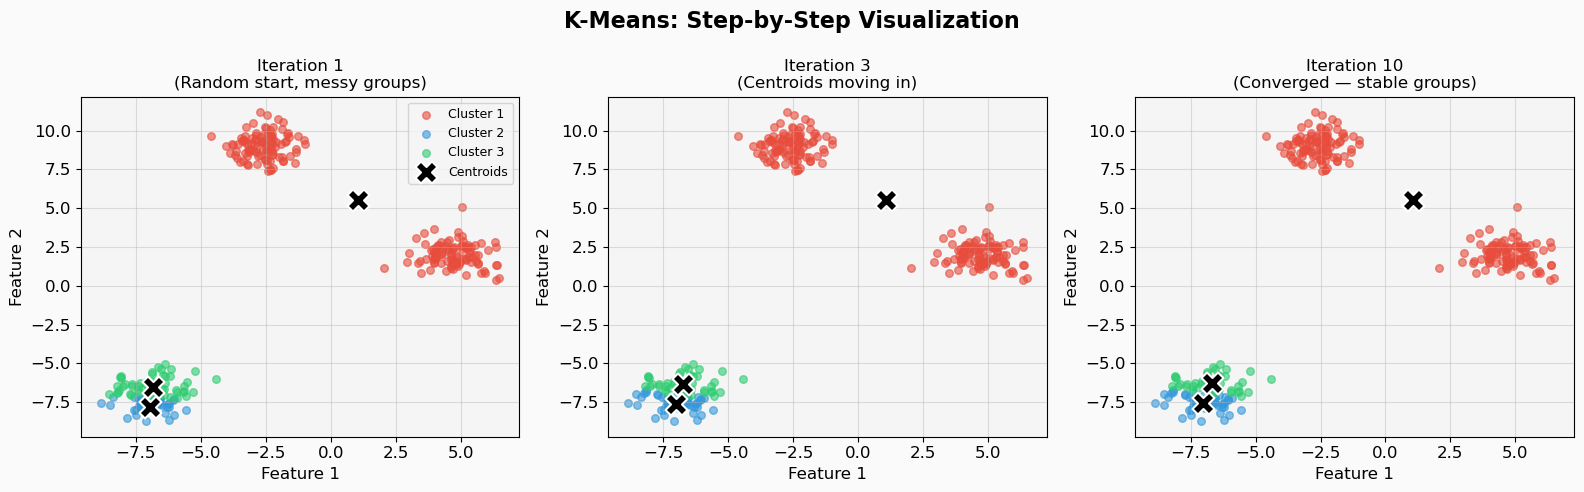

Final inertia (compactness): 5482.74


In [2]:
# --- Generate synthetic 2D data with 3 natural clusters ---
np.random.seed(42)
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=0.8, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('K-Means: Step-by-Step Visualization', fontsize=16, fontweight='bold')

iterations_to_show = [1, 3, 10]
titles = ['Iteration 1\n(Random start, messy groups)',
          'Iteration 3\n(Centroids moving in)',
          'Iteration 10\n(Converged — stable groups)']

for ax, n_iter, title in zip(axes, iterations_to_show, titles):
    km = KMeans(n_clusters=3, max_iter=n_iter, n_init=1,
                init='random', random_state=0)
    labels = km.fit_predict(X)
    centers = km.cluster_centers_

    for k in range(3):
        mask = labels == k
        ax.scatter(X[mask, 0], X[mask, 1], c=COLORS[k], alpha=0.6, s=30, label=f'Cluster {k+1}')

    ax.scatter(centers[:, 0], centers[:, 1],
               c='black', marker='X', s=250, zorder=5,
               edgecolors='white', linewidths=1.5, label='Centroids')

    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    if ax == axes[0]:
        ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('kmeans_steps.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Final inertia (compactness): {km.inertia_:.2f}")

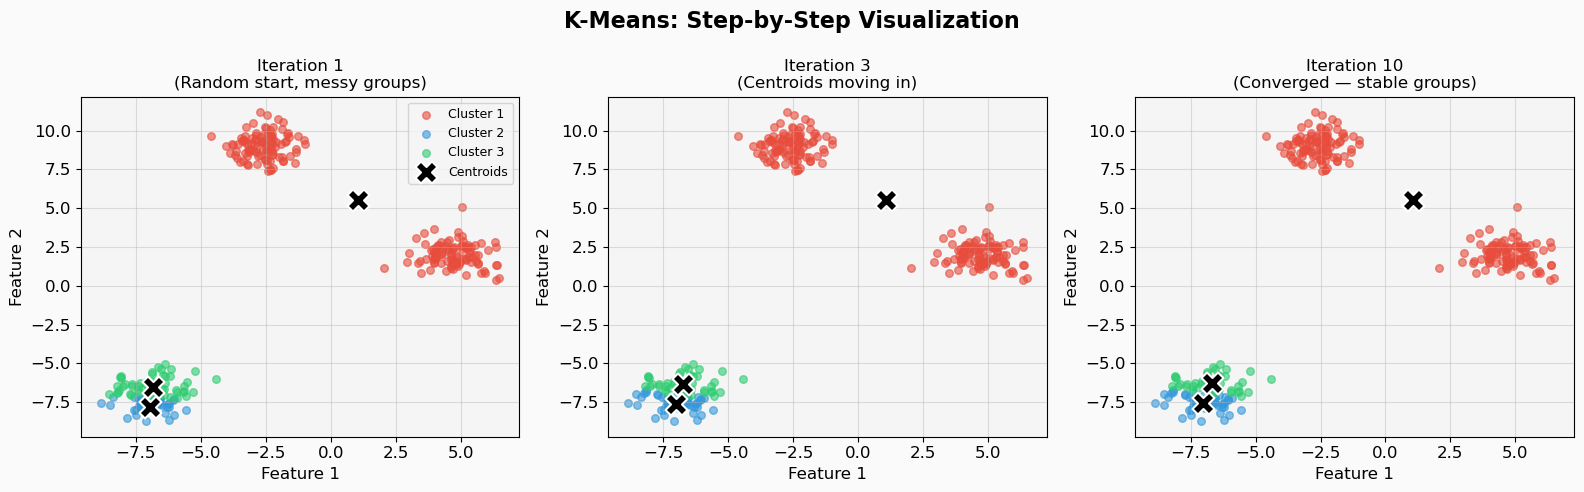

Final inertia (compactness): 5482.74


In [3]:
# --- STEP 1: Generate synthetic 2D data with 3 natural clusters ---
# Set a seed so the random data is the same every time you run the code
np.random.seed(42) 

# Create 300 data points (X) grouped around 3 centers with some overlap (cluster_std)
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=0.8, random_state=42)

# --- STEP 2: Prepare the visualization layout ---
# Create a row of 3 subplots to show the "story" of the algorithm moving over time
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('K-Means: Step-by-Step Visualization', fontsize=16, fontweight='bold')

# Define which snapshots of the training we want to see
iterations_to_show = [1, 3, 10]
titles = ['Iteration 1\n(Random start, messy groups)',
          'Iteration 3\n(Centroids moving in)',
          'Iteration 10\n(Converged — stable groups)']

# --- STEP 3: Loop through the chosen iterations and plot results ---
for ax, n_iter, title in zip(axes, iterations_to_show, titles):
    # Initialize K-Means: 
    # n_init=1 and init='random' ensures we start from random points rather than the smart 'k-means++'
    # max_iter=n_iter forces the algorithm to stop exactly at the step we want to visualize
    km = KMeans(n_clusters=3, max_iter=n_iter, n_init=1,
                init='random', random_state=0)
    
    # Run the algorithm and get cluster assignments (labels) and final center positions
    labels = km.fit_predict(X)
    centers = km.cluster_centers_

    # Plot each cluster one by one with its assigned color
    for k in range(3):
        mask = labels == k  # Identify points belonging to current cluster 'k'
        ax.scatter(X[mask, 0], X[mask, 1], c=COLORS[k], alpha=0.6, s=30, label=f'Cluster {k+1}')

    # Plot the centroids (the 'X' markers) on top of the data points
    ax.scatter(centers[:, 0], centers[:, 1],
               c='black', marker='X', s=250, zorder=5,
               edgecolors='white', linewidths=1.5, label='Centroids')

    # Add labels and formatting to each subplot
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    if ax == axes[0]: # Only show the legend on the first plot to avoid clutter
        ax.legend(fontsize=9)

# Finalize the layout and save the image
plt.tight_layout()
plt.savefig('kmeans_steps.png', dpi=120, bbox_inches='tight')
plt.show()

# Print the inertia: this represents how "tight" the clusters are (lower is better)
print(f"Final inertia (compactness): {km.inertia_:.2f}")

## 🔬 Worked Example 2: Customer Segmentation

We apply **K-Means clustering** to the *Mall Customer Segmentation* dataset to identify distinct shopper archetypes based on:

*   **Annual Income**: Yearly earnings (scaled).
*   **Spending Score**: A 1–100 rating based on purchasing patterns.

### Key Segments Identified ($k=5$):
*   **Target Shoppers**: High income, high spending.
*   **Careful Consumers**: High income, low spending.
*   **Balanced Shoppers**: Average income, average spending.
*   **Impulsive Shoppers**: Low income, high spending.
*   **Frugal Shoppers**: Low income, low spending.



> **Insight**: Using $k=5$ clusters provides the most actionable business intelligence for this dataset.

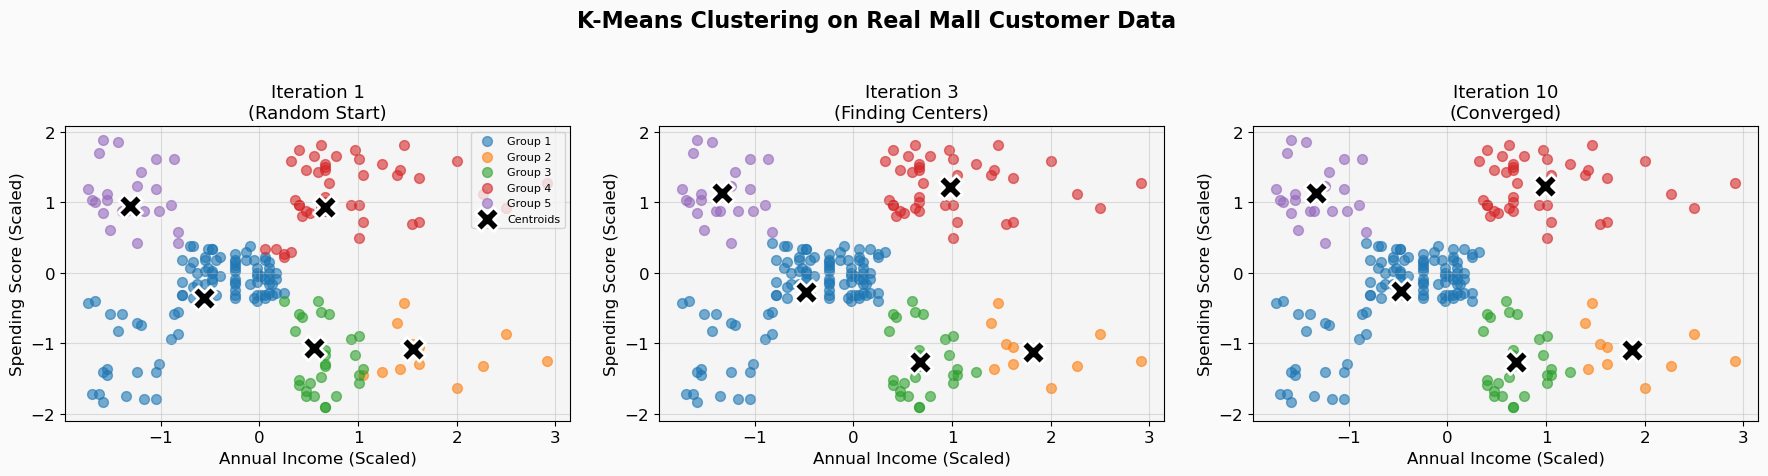

Final WCSS (Within-Cluster Sum of Squares): 98.81
Cluster Discovery Complete. Groups represent segments like 'High Income/Low Spenders' or 'High Income/High Spenders'.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs

# --- STEP 1: DATA LOADING & PREPROCESSING ---
# Download from: https://raw.githubusercontent.com/kennedykwangari/Mall-Customer-Segmentation-Data/master/Mall_Customers.csv
# For this script, we will load it directly from the URL
url = "https://raw.githubusercontent.com/kennedykwangari/Mall-Customer-Segmentation-Data/master/Mall_Customers.csv"
df = pd.read_csv(url)

# Select features: Annual Income and Spending Score
# These are columns 3 and 4 (0-indexed)
X_raw = df.iloc[:, [3, 4]].values

# Real-world data needs scaling because the units/ranges differ
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

# --- STEP 2: VISUALIZATION SETUP ---
# Defining colors for up to 5 clusters
COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('K-Means Clustering on Real Mall Customer Data', fontsize=16, fontweight='bold')

# We want to see how the algorithm "thinks" at different stages
iterations_to_show = [1, 3, 10]
titles = ['Iteration 1\n(Random Start)', 
          'Iteration 3\n(Finding Centers)', 
          'Iteration 10\n(Converged)']

# --- STEP 3: THE K-MEANS LOOP ---
for ax, n_iter, title in zip(axes, iterations_to_show, titles):
    # n_clusters=5 is optimal for this dataset
    # n_init=1 and init='random' allows us to see the step-by-step movement
    km = KMeans(n_clusters=5, max_iter=n_iter, n_init=1, init='random', random_state=42)
    
    # Fit the model and predict clusters
    labels = km.fit_predict(X)
    centers = km.cluster_centers_

    # Plot each of the 5 clusters
    for k in range(5):
        mask = labels == k
        ax.scatter(X[mask, 0], X[mask, 1], c=COLORS[k], alpha=0.6, s=50, label=f'Group {k+1}')

    # Plot the centroids (the 'X' marks)
    ax.scatter(centers[:, 0], centers[:, 1], 
               c='black', marker='X', s=300, zorder=10, 
               edgecolors='white', linewidths=2, label='Centroids')

    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Annual Income (Scaled)')
    ax.set_ylabel('Spending Score (Scaled)')
    
    if ax == axes[0]:
        ax.legend(loc='upper right', fontsize=8)

# Final formatting
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- STEP 4: EVALUATION ---
print(f"Final WCSS (Within-Cluster Sum of Squares): {km.inertia_:.2f}")
print("Cluster Discovery Complete. Groups represent segments like 'High Income/Low Spenders' or 'High Income/High Spenders'.")

## 🔬 Worked Example 3: The Elbow Method — Choosing K

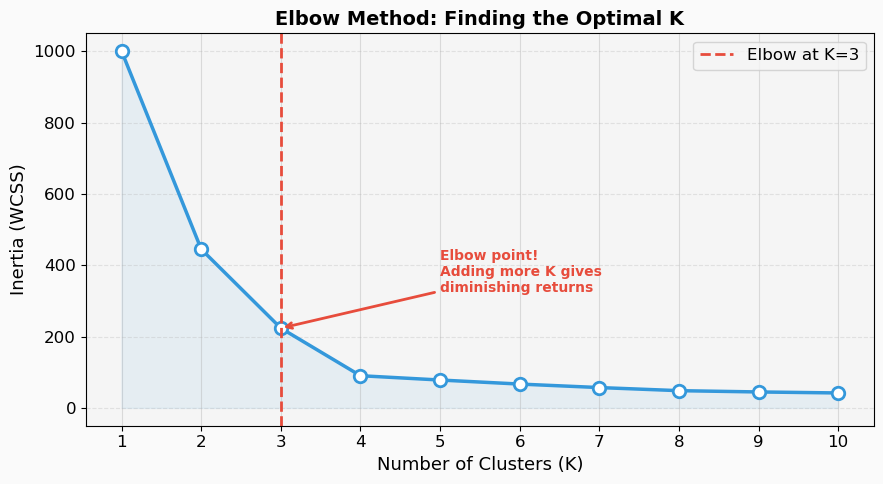

Inertia values:
K=1: 1000.0
K=2: 444.8
K=3: 223.5
K=4: 90.2
K=5: 78.1
K=6: 66.8
K=7: 57.0
K=8: 48.3
K=9: 44.7
K=10: 41.9


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. DATA PREPARATION
# ==========================================

# OPTION A: Generate synthetic data (for demonstration)
from sklearn.datasets import make_blobs
X, _ = make_blobs(n_samples=500, centers=4, cluster_std=0.60, random_state=0)
data = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])

# OPTION B: Load your actual data (Uncomment the line below to use your CSV)
# data = pd.read_csv('your_customer_data.csv')

# Ensure only numeric columns are used for scaling
# (K-Means cannot handle strings/categories directly)
numeric_data = data.select_dtypes(include=[np.number])

# THE FIX: Define and create X_scaled
scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_data)

# ==========================================
# 2. ELBOW METHOD CALCULATION
# ==========================================
inertias = []
K_range = range(1, 11)

for k in K_range:
    # n_init=10 is standard to ensure the algorithm runs with 10 different seeds
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# ==========================================
# 3. VISUALIZATION
# ==========================================
fig, ax = plt.subplots(figsize=(9, 5))

# Plotting the inertia curve
ax.plot(K_range, inertias, 'o-', color='#3498DB', linewidth=2.5, 
        markersize=9, markerfacecolor='white', markeredgewidth=2)

# Highlighting the "Elbow" (assuming 3 is the optimal K for this data)
# Adjust x=3 if your specific data suggests a different elbow point
ax.axvline(x=3, color='#E74C3C', linestyle='--', linewidth=2, label='Elbow at K=3')

# Aesthetics
ax.fill_between(K_range, inertias, alpha=0.08, color='#3498DB')
ax.set_xlabel('Number of Clusters (K)', fontsize=13)
ax.set_ylabel('Inertia (WCSS)', fontsize=13)
ax.set_title('Elbow Method: Finding the Optimal K', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.set_xticks(list(K_range))
ax.grid(axis='y', linestyle='--', alpha=0.3)

# Annotation for students/users
# Use a safety check to ensure index 2 (K=3) exists before annotating
if len(inertias) >= 3:
    ax.annotate('Elbow point!\nAdding more K gives\ndiminishing returns',
                xy=(3, inertias[2]), xytext=(5, inertias[2] + (max(inertias)*0.1)),
                arrowprops=dict(arrowstyle='->', color='#E74C3C', lw=2),
                fontsize=10, color='#E74C3C', fontweight='bold')

plt.tight_layout()
# Save and show
# plt.savefig('elbow_method.png', dpi=120, bbox_inches='tight')
plt.show()

# Print out results for verification
print("Inertia values:")
for k, v in zip(K_range, inertias):
    print(f"K={k}: {v:.1f}")

---
## 🔨 TO-DO 1: K-Means on a New Dataset

### Your Tasks:

**Task A:** Generate a dataset with **5 clusters** (not 3) and apply K-Means. Use `make_blobs` with `centers=5`.

**Task B:** Run the Elbow Method for K=1 to 12 and identify the correct elbow point.

**Task C:** Visualize the final clusters with different colors for each cluster.

**Task D:** Try `cluster_std=2.0` (overlapping clusters). Does K-Means still work well? Why or why not?

> **Hint:** Use `make_blobs(n_samples=500, centers=5, cluster_std=1.0, random_state=99)`

In [ ]:
# ===== TO-DO Task A & B: Generate data and run Elbow Method =====
# Your code here ↓

# Step 1: Generate data with 5 clusters
# X_todo, _ = make_blobs( ... )

# Step 2: Scale the data
# scaler_todo = ...
# X_todo_scaled = ...

# Step 3: Run elbow method for K=1 to 12
# inertias_todo = []
# for k in range(1, 13):
#     ...

# Step 4: Plot the elbow curve
# plt.plot( ... )
# plt.xlabel( ... )
# ...

raise NotImplementedError("Complete Task A & B above!")

In [ ]:
# ===== TO-DO Task C: Visualize clusters =====
# Use the best K you found from the elbow method above
# Your code here ↓

# best_k = ???
# km_todo = KMeans(n_clusters=best_k, random_state=42, n_init=10)
# labels_todo = km_todo.fit_predict(X_todo_scaled)

# Plot each cluster with a different color using COLORS list
# for k in range(best_k):
#     ...

# Don't forget to plot the centroids!

raise NotImplementedError("Complete Task C above!")

In [ ]:
# ===== TO-DO Task D: Experiment with overlapping clusters =====
# Regenerate with cluster_std=2.0 and repeat the clustering
# Compare the inertia and visual quality
# Your code here ↓

raise NotImplementedError("Complete Task D above!")

## ❓ Reflection Questions — K-Means

Answer in the cell below (double-click to edit):

1. **Why must we scale features before K-Means?** What happens if `TotalSpend` is in dollars and `LoyaltyMonths` is in months — won't the algorithm be biased?

2. **Is K-Means deterministic?** Run it twice without `random_state`. Do you get the same clusters? Why or why not?

3. **What is inertia measuring?** If we increase K to the number of data points, what would inertia be?

4. **Name one real-world use case** where K-Means would be appropriate, and one where it would fail badly. Explain.

5. **Looking at Task D**, does K-Means handle overlapping clusters well? What's the fundamental reason for its limitation?

### ✏️ Your Answers (Double-click to edit):

1. *Your answer here...*

2. *Your answer here...*

3. *Your answer here...*

4. *Your answer here...*

5. *Your answer here...*

---
# 🌫️ PART 2: Gaussian Mixture Models (GMM)

## Hard vs. Soft Assignments

| Feature | K-Means | GMM |
|---|---|---|
| Assignment type | Hard (one cluster only) | Soft (probabilities) |
| Cluster shape | Spherical | Elliptical (flexible) |
| Output | Cluster label | Probability per cluster |
| Handles overlap? | Poorly | Yes |

**GMM models each cluster as a Gaussian (bell curve) in multi-dimensional space.**  
The algorithm learns each cloud's *center* (mean) and *shape* (covariance).

A point near the boundary of two clusters gets, for example: **70% Cluster A, 30% Cluster B** — much more realistic!

## 🔬 Worked Example 4: GMM vs K-Means on Overlapping Data

In [ ]:
# Generate overlapping clusters — K-Means's weakness
np.random.seed(10)
X_overlap, _ = make_blobs(n_samples=400, centers=3, cluster_std=1.8, random_state=10)

# Fit both models
km_overlap = KMeans(n_clusters=3, random_state=42, n_init=10)
gmm_overlap = GaussianMixture(n_components=3, covariance_type='full', random_state=42)

labels_km = km_overlap.fit_predict(X_overlap)
labels_gmm = gmm_overlap.fit_predict(X_overlap)
probs_gmm = gmm_overlap.predict_proba(X_overlap)  # soft probabilities!

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('K-Means vs GMM on Overlapping Clusters', fontsize=14, fontweight='bold')

# K-Means result
for k in range(3):
    mask = labels_km == k
    axes[0].scatter(X_overlap[mask, 0], X_overlap[mask, 1],
                    c=COLORS[k], alpha=0.7, s=30)
axes[0].scatter(km_overlap.cluster_centers_[:, 0], km_overlap.cluster_centers_[:, 1],
                c='black', marker='X', s=200, zorder=5, edgecolors='white', linewidths=1.5)
axes[0].set_title('K-Means\n(Hard assignments)', fontsize=12)
axes[0].set_xlabel('Feature 1')

# GMM result
for k in range(3):
    mask = labels_gmm == k
    axes[1].scatter(X_overlap[mask, 0], X_overlap[mask, 1],
                    c=COLORS[k], alpha=0.7, s=30)
axes[1].set_title('GMM\n(Hard assignments from argmax)', fontsize=12)
axes[1].set_xlabel('Feature 1')

# GMM uncertainty visualization (how confident is the model?)
# Color by maximum probability (confidence): lower = more uncertain
max_prob = probs_gmm.max(axis=1)
sc = axes[2].scatter(X_overlap[:, 0], X_overlap[:, 1],
                     c=max_prob, cmap='RdYlGn', s=30, vmin=0.3, vmax=1.0)
plt.colorbar(sc, ax=axes[2], label='Max cluster probability')
axes[2].set_title('GMM Confidence\n(Red = uncertain, Green = sure)', fontsize=12)
axes[2].set_xlabel('Feature 1')

plt.tight_layout()
plt.savefig('gmm_vs_kmeans.png', dpi=120, bbox_inches='tight')
plt.show()

# Show some example soft assignments
print("\n📊 Sample Soft Probability Assignments (GMM):")
sample_df = pd.DataFrame(probs_gmm[:8].round(3),
                          columns=['P(Cluster 0)', 'P(Cluster 1)', 'P(Cluster 2)'])
print(sample_df.to_string(index=False))

## 🔬 Worked Example 5: Anomaly Detection (Fraud Detection)

In [ ]:
# Simulate bank transactions (mostly legitimate, a few fraudulent)
np.random.seed(55)

# Legitimate transactions: 2 clusters (small everyday, larger occasional)
legit_small  = np.column_stack([np.random.normal(30, 10, 400),
                                 np.random.normal(12, 2, 400)])   # (amount, hour)
legit_large  = np.column_stack([np.random.normal(200, 40, 150),
                                 np.random.normal(15, 3, 150)])
legit = np.vstack([legit_small, legit_large])

# Fraudulent transactions: unusual amounts at unusual hours
fraud = np.column_stack([np.random.normal(900, 100, 30),
                          np.random.normal(3, 1, 30)])   # 3am transactions

# Train GMM ONLY on legitimate data
gmm_fraud = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
gmm_fraud.fit(legit)

# Score ALL transactions (including fraud) — lower log-likelihood = more anomalous
all_transactions = np.vstack([legit, fraud])
log_likelihood = gmm_fraud.score_samples(all_transactions)

# Set a threshold: flag the bottom 5% as suspicious
threshold = np.percentile(log_likelihood, 5)
is_flagged = log_likelihood < threshold

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('GMM Anomaly Detection: Fraud Identification', fontsize=14, fontweight='bold')

# Scatter: all transactions colored by flagged/not
n_legit = len(legit)
true_labels = np.array(['Legitimate']*n_legit + ['Fraud']*len(fraud))

axes[0].scatter(all_transactions[~is_flagged, 0], all_transactions[~is_flagged, 1],
                c='#3498DB', alpha=0.5, s=25, label='Normal')
axes[0].scatter(all_transactions[is_flagged, 0], all_transactions[is_flagged, 1],
                c='#E74C3C', s=80, marker='D', zorder=5, label='⚠️ Flagged as Suspicious')
axes[0].set_xlabel('Transaction Amount ($)')
axes[0].set_ylabel('Hour of Day')
axes[0].set_title('Transaction Space: Flagged vs Normal')
axes[0].legend()

# Log-likelihood distribution
axes[1].hist(log_likelihood[:n_legit], bins=30, color='#3498DB', alpha=0.6, label='Legitimate', density=True)
axes[1].hist(log_likelihood[n_legit:], bins=10, color='#E74C3C', alpha=0.7, label='Fraud', density=True)
axes[1].axvline(x=threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold ({threshold:.1f})')
axes[1].set_xlabel('Log-Likelihood Score')
axes[1].set_ylabel('Density')
axes[1].set_title('Score Distribution\n(Lower = more suspicious)')
axes[1].legend()

plt.tight_layout()
plt.savefig('gmm_fraud_detection.png', dpi=120, bbox_inches='tight')
plt.show()

flagged_fraud = np.sum(is_flagged[n_legit:])
flagged_legit = np.sum(is_flagged[:n_legit])
print(f"\n📊 Detection Results:")
print(f"   Fraud transactions flagged: {flagged_fraud}/{len(fraud)} ({100*flagged_fraud/len(fraud):.1f}%)")
print(f"   Legitimate transactions falsely flagged: {flagged_legit}/{n_legit} ({100*flagged_legit/n_legit:.1f}%)")

---
## 🔨 TO-DO 2: GMM — Model Selection & Exploration

### Your Tasks:

**Task A:** Fit GMMs with `n_components` = 1, 2, 3, 4, 5 on the customer dataset from Part 1. For each, record its **BIC score** (`gmm.bic(X_scaled)`). Plot BIC vs. number of components — the *lowest* BIC wins.

**Task B:** Using the best GMM from Task A, print the **soft probability assignment** for 5 sample customers. Identify which customers are "on the boundary" between two segments.

**Task C:** Try different `covariance_type` values: `'full'`, `'tied'`, `'diag'`, `'spherical'`. Which gives the lowest BIC? What does each type assume about cluster shape?

> **Hint:** `GaussianMixture(n_components=3, covariance_type='full').fit(X_scaled)`

In [ ]:
# ===== TO-DO Task A: BIC model selection =====
# Your code here ↓

# bic_scores = []
# for n in range(1, 6):
#     gmm = GaussianMixture(n_components=n, covariance_type='full', random_state=42)
#     gmm.fit( ... )
#     bic_scores.append( gmm.bic( ... ) )

# Plot BIC vs n_components
# plt.plot( ... )

raise NotImplementedError("Complete Task A above!")

In [ ]:
# ===== TO-DO Task B: Soft assignments for 5 customers =====
# Your code here ↓

# best_gmm = GaussianMixture(n_components=???, ...)
# best_gmm.fit(X_scaled)
# probs = best_gmm.predict_proba(X_scaled)

# Print probabilities for 5 sample customers
# ...

# Which customers have max probability < 0.7? (boundary customers)
# ...

raise NotImplementedError("Complete Task B above!")

In [ ]:
# ===== TO-DO Task C: Compare covariance types =====
# Your code here ↓

# cov_types = ['full', 'tied', 'diag', 'spherical']
# for cov in cov_types:
#     gmm = GaussianMixture(n_components=3, covariance_type=cov, random_state=42)
#     gmm.fit(X_scaled)
#     print(f"{cov}: BIC = {gmm.bic(X_scaled):.2f}")

raise NotImplementedError("Complete Task C above!")

## ❓ Reflection Questions — GMM

1. **What is BIC** and why do we prefer lower BIC? How is it different from just picking the highest likelihood?

2. **Why train the fraud detection GMM on legitimate data only?** What would happen if we included fraud transactions in training?

3. **In Task B**, what does it mean for a customer to have soft assignments of `[0.51, 0.49, 0.00]`? Is this a problem or useful information?

4. **Compare the threshold choice in fraud detection**: If we lower the threshold (flag the bottom 1% instead of 5%), what happens to fraud detection rate and false alarms? What is this tradeoff called?

5. **When would you choose GMM over K-Means?** Give two concrete scenarios.

### ✏️ Your Answers (Double-click to edit):

1. *Your answer here...*

2. *Your answer here...*

3. *Your answer here...*

4. *Your answer here...*

5. *Your answer here...*

---
# 📉 PART 3: Principal Component Analysis (PCA)

## The Curse of Dimensionality

Real datasets often have dozens or hundreds of features. Extra features can:
- Add **noise** that drowns out real patterns
- Make algorithms **slow** (data is large)
- Make **visualization impossible** (we can only see 2D/3D)

**PCA** finds the directions of *maximum variance* in your data and projects everything onto those directions.  
Result: fewer dimensions, but most information preserved.

```
Original data (784 dimensions)
         ↓  PCA
Compressed data (10 dimensions)  ← Most information kept!
```

## 🔬 Worked Example 6: PCA on the Digits Dataset

We'll use the famous MNIST-style **digits dataset** (8×8 = 64 dimensions of pixel intensity).

In [ ]:
# Load digits dataset: 1797 images, each 8x8 = 64 features
digits = load_digits()
X_digits = digits.data         # shape: (1797, 64)
y_digits = digits.target       # labels 0-9

print(f"Dataset shape: {X_digits.shape}")
print(f"Each image is {digits.images[0].shape} pixels")

# Show some sample digits
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
fig.suptitle('Sample Handwritten Digits (8×8 pixels = 64 features each)', fontsize=13, fontweight='bold')
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='Blues')
    ax.set_title(f'Label: {y_digits[i]}', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig('digits_samples.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# Apply PCA and examine explained variance
scaler_pca = StandardScaler()
X_digits_scaled = scaler_pca.fit_transform(X_digits)

pca_full = PCA(random_state=42)
pca_full.fit(X_digits_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

# Find how many PCs explain 90%, 95%, 99%
for target in [0.90, 0.95, 0.99]:
    n_components = np.argmax(cumulative >= target) + 1
    print(f"   {int(target*100)}% variance explained by {n_components} components (out of 64)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PCA: How Many Components Do We Need?', fontsize=14, fontweight='bold')

# Individual explained variance
axes[0].bar(range(1, 21), explained[:20] * 100, color='#3498DB', edgecolor='white')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('% Variance Explained')
axes[0].set_title('Variance per Component (first 20)')

# Cumulative explained variance
axes[1].plot(range(1, len(cumulative)+1), cumulative * 100, color='#2ECC71', linewidth=2.5)
for target, color in [(90, '#E74C3C'), (95, '#F39C12'), (99, '#9B59B6')]:
    n = np.argmax(cumulative >= target/100) + 1
    axes[1].axhline(y=target, color=color, linestyle='--', alpha=0.7, label=f'{target}% @ PC{n}')
    axes[1].axvline(x=n, color=color, linestyle=':', alpha=0.5)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative % Variance Explained')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
axes[1].set_ylim(0, 102)

plt.tight_layout()
plt.savefig('pca_variance.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# Project digits to 2D for visualization
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_digits_scaled)

fig, ax = plt.subplots(figsize=(11, 8))
scatter_colors = plt.cm.tab10(np.linspace(0, 1, 10))

for digit in range(10):
    mask = y_digits == digit
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=[scatter_colors[digit]], alpha=0.6, s=25, label=str(digit))

ax.set_title(f'Digits Dataset Projected to 2D via PCA\n'
             f'(Captures {pca_2d.explained_variance_ratio_.sum()*100:.1f}% of variance)',
             fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(title='Digit', bbox_to_anchor=(1.01, 1), loc='upper left', ncol=1)
plt.tight_layout()
plt.savefig('pca_2d_digits.png', dpi=120, bbox_inches='tight')
plt.show()
print("Notice how similar digits cluster together even in just 2 dimensions!")

In [ ]:
# Image reconstruction: how many components until quality is good enough?
n_components_list = [1, 5, 10, 20, 40, 64]
sample_idx = 7  # choose a sample digit to reconstruct

fig, axes = plt.subplots(1, len(n_components_list) + 1, figsize=(16, 3))
fig.suptitle('PCA Image Compression: Reconstruction Quality vs. Components',
             fontsize=13, fontweight='bold')

# Original
axes[0].imshow(digits.images[sample_idx], cmap='Blues')
axes[0].set_title('Original\n(64 dims)', fontsize=10)
axes[0].axis('off')

for ax, n in zip(axes[1:], n_components_list):
    pca_n = PCA(n_components=n, random_state=42)
    X_reduced = pca_n.fit_transform(X_digits_scaled)
    X_reconstructed = pca_n.inverse_transform(X_reduced)
    X_reconstructed = scaler_pca.inverse_transform(X_reconstructed)
    
    img_reconstructed = X_reconstructed[sample_idx].reshape(8, 8)
    var_kept = pca_n.explained_variance_ratio_.sum() * 100
    
    ax.imshow(img_reconstructed, cmap='Blues')
    ax.set_title(f'{n} PCs\n({var_kept:.0f}% var)', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('pca_reconstruction.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 🔨 TO-DO 3: PCA — Exploration & Pipeline

### Your Tasks:

**Task A:** Apply PCA to reduce the digits dataset to **2 components**, then run **K-Means** on the 2D data. Compare the clustering accuracy to clustering on the original 64D data. Which is better?

**Task B:** Try keeping 10 components instead of 2 for the K-Means step. Does accuracy improve?

**Task C:** Use `pca.components_` to visualize the first 8 principal components as 8×8 images. What patterns do they capture?

> **Hint for Task A:** Use `from sklearn.metrics import adjusted_rand_score` to compare cluster labels to true digit labels.

In [ ]:
# ===== TO-DO Task A: PCA + K-Means pipeline =====
from sklearn.metrics import adjusted_rand_score
# Your code here ↓

# Step 1: Reduce to 2D with PCA
# pca_2 = PCA(n_components=2, random_state=42)
# X_2d_todo = pca_2.fit_transform(X_digits_scaled)

# Step 2: K-Means on 2D data (use n_clusters=10 for the 10 digits)
# km_2d = KMeans(n_clusters=10, random_state=42, n_init=10)
# labels_2d = km_2d.fit_predict(X_2d_todo)

# Step 3: K-Means on original 64D data
# km_64d = ...
# labels_64d = ...

# Step 4: Compare ARI scores (1.0 = perfect, 0.0 = random)
# ari_2d = adjusted_rand_score(y_digits, labels_2d)
# ari_64d = adjusted_rand_score(y_digits, labels_64d)
# print(f"ARI (2D PCA): {ari_2d:.3f}")
# print(f"ARI (64D original): {ari_64d:.3f}")

raise NotImplementedError("Complete Task A above!")

In [ ]:
# ===== TO-DO Task B: Try 10 components =====
# Repeat Task A but with n_components=10
# Your code here ↓

raise NotImplementedError("Complete Task B above!")

In [ ]:
# ===== TO-DO Task C: Visualize principal components =====
# The first 8 PCs are stored in pca_full.components_[:8]
# Each is a 64-element vector that can be reshaped to 8x8
# Your code here ↓

# fig, axes = plt.subplots(2, 4, figsize=(12, 6))
# for i, ax in enumerate(axes.flat):
#     component = pca_full.components_[i].reshape(8, 8)
#     ax.imshow(component, cmap='RdBu_r')  # diverging colormap — positive vs negative
#     ax.set_title(f'PC{i+1}\n({pca_full.explained_variance_ratio_[i]*100:.1f}% var)')
#     ax.axis('off')

raise NotImplementedError("Complete Task C above!")

## ❓ Reflection Questions — PCA

1. **Why do we scale (StandardScaler) before PCA?** What happens if features have very different ranges?

2. **In the reconstruction experiment**, how many components are needed before the digit is clearly recognizable? What does this tell you about redundancy in pixel data?

3. **From Task A/B**, did adding more PCA components (2 → 10) improve K-Means clustering? Why might too few dimensions hurt? Why might the original 64D also sometimes perform worse than the right number of PCs?

4. **What do the principal component images (Task C) represent visually?** What kind of patterns do early PCs capture vs. later PCs?

5. **PCA is a linear method**. What does this mean, and what kind of data structure might PCA fail to capture? (Bonus: what non-linear alternative exists?)

### ✏️ Your Answers (Double-click to edit):

1. *Your answer here...*

2. *Your answer here...*

3. *Your answer here...*

4. *Your answer here...*

5. *Your answer here...*

---
# 🏆 BONUS CHALLENGE: Full Unsupervised Learning Pipeline

Combine everything you've learned into one pipeline!

### Task:
1. Load the digits dataset
2. Scale it
3. Reduce to **20 components** with PCA
4. Fit a **GMM** with 10 components on the reduced data
5. Compare GMM's BIC to K-Means inertia for K=10
6. Visualize the GMM soft-assignment uncertainty (which digits are most ambiguous?)
7. **Extra challenge:** Use the 2D PCA projection to visualize which digits the GMM is most uncertain about

In [ ]:
# ===== BONUS CHALLENGE =====
# Your code here ↓

raise NotImplementedError("Complete the bonus challenge!")

---
# 📚 Summary: What You've Learned

| Algorithm | Type | Key Idea | When to Use |
|---|---|---|---|
| **K-Means** | Hard clustering | Assign each point to nearest centroid | Distinct, spherical clusters |
| **GMM** | Soft clustering | Model data as mixture of Gaussians | Overlapping clusters, need probabilities |
| **PCA** | Dimensionality reduction | Keep directions of max variance | Too many features, visualization, noise removal |

## Key Takeaways
- **Always scale your data** before K-Means, GMM, or PCA
- **Use the Elbow Method / BIC** to choose the number of clusters
- **PCA + Clustering** is a powerful combination for high-dimensional data
- **Soft assignments (GMM)** give you uncertainty information that hard assignments (K-Means) hide
- **Anomaly detection** with GMM works by flagging points with low log-likelihood

---
*Notebook complete! Make sure you've answered all the Reflection Questions and completed all To-Do tasks.*